Saving tourism_dataset.csv to tourism_dataset (1).csv
Dataset Shape: (5989, 7)

Columns:
Index(['Location', 'Country', 'Category', 'Visitors', 'Rating', 'Revenue',
       'Accommodation_Available'],
      dtype='object')

Missing Values After Cleaning:
Location                   0
Country                    0
Category                   0
Visitors                   0
Rating                     0
Revenue                    0
Accommodation_Available    0
dtype: int64

--- SUPERVISED LEARNING METRICS ---
Accuracy: 0.48664440734557596
Precision: 0.4892394345862262
Recall: 0.48664440734557596
F1 Score: 0.4711231632177431

Classification Report:
              precision    recall  f1-score   support

       False       0.48      0.66      0.56       586
        True       0.50      0.32      0.39       612

    accuracy                           0.49      1198
   macro avg       0.49      0.49      0.47      1198
weighted avg       0.49      0.49      0.47      1198



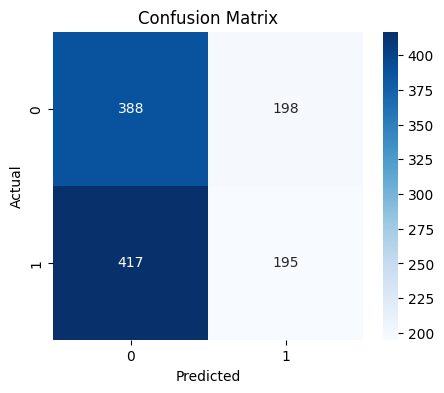


--- UNSUPERVISED LEARNING METRICS ---
Silhouette Score: 0.00015123229155981726
Davies-Bouldin Index: 48.51655501800428


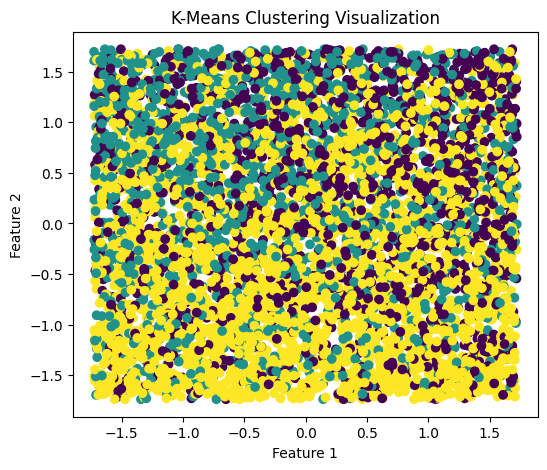

In [ ]:
# USAMA ANSARI (221206)
# =====================================
# STEP 1: Import Required Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# =====================================
# STEP 2: Upload & Load Dataset
# =====================================
uploaded = files.upload()   # Upload tourism_dataset.csv
data = pd.read_csv("tourism_dataset.csv")

print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns)

# =====================================
# STEP 3: Data Cleaning (Imputation)
# =====================================
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[num_cols] = num_imputer.fit_transform(data[num_cols])
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

# =====================================
# STEP 4: Encode Categorical Data
# =====================================
data_encoded = pd.get_dummies(data, drop_first=True)

# =====================================
# SUPERVISED LEARNING
# =====================================
# CHANGE 'TargetColumn' TO YOUR ACTUAL TARGET COLUMN
X = data_encoded.drop("Accommodation_Available_Yes", axis=1)
y = data_encoded["Accommodation_Available_Yes"]

# =====================================
# STEP 5: Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# STEP 6: Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =====================================
# STEP 7: Supervised Model (Logistic Regression)
# =====================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =====================================
# STEP 8: Supervised Evaluation Metrics
# =====================================
print("\n--- SUPERVISED LEARNING METRICS ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================
# UNSUPERVISED LEARNING
# =====================================
# STEP 9: Prepare Data for Clustering
# =====================================
X_unsupervised = data_encoded.copy()

scaler = StandardScaler()
X_unsupervised_scaled = scaler.fit_transform(X_unsupervised)

# =====================================
# STEP 10: K-Means Clustering
# =====================================
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_unsupervised_scaled)

# =====================================
# STEP 11: Unsupervised Evaluation Metrics
# =====================================
sil_score = silhouette_score(X_unsupervised_scaled, cluster_labels)
db_score = davies_bouldin_score(X_unsupervised_scaled, cluster_labels)

print("\n--- UNSUPERVISED LEARNING METRICS ---")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)

# =====================================
# STEP 12: Cluster Visualization (2D)
# =====================================
plt.figure(figsize=(6,5))
plt.scatter(
    X_unsupervised_scaled[:,0],
    X_unsupervised_scaled[:,1],
    c=cluster_labels,
    cmap='viridis'
)
plt.title("K-Means Clustering Visualization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()